In [1]:
import time
notebook_start_time = time.time() # ⏱️ Start the global timer here

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import pandas as pd
import random, os
import shutil
import matplotlib.pyplot as plt
from matplotlib.image import imread
# Instead of importing from keras.preprocessing.image, import from tf.keras.utils.image_dataset_from_directory
# or tf.keras.preprocessing.image_dataset_from_directory
from tensorflow.keras.preprocessing.image import ImageDataGenerator # If using older version of tensorflow
from tensorflow.keras.metrics import categorical_accuracy
from sklearn.model_selection import train_test_split

I0000 00:00:1788767241.662357     874 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788767242.038991     874 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788767244.588829     874 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("CUDA available:", len(tf.config.list_physical_devices('GPU')) > 0)
print("GPUs:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
CUDA available: True
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


W0000 00:00:1788767249.083246     874 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


In [3]:
import tensorflow as tf
import time

with tf.device('/GPU:0'):
    a = tf.random.normal([5000, 5000])
    b = tf.random.normal([5000, 5000])

start = time.time()
c = tf.matmul(a, b)

print("Device:", c.device)
print("Time:", round(time.time() - start, 3), "seconds")

W0000 00:00:1788767249.114068     874 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1788767249.313833     874 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5262 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 12.0a


Device: /job:localhost/replica:0/task:0/device:GPU:0
Time: 0.214 seconds


In [4]:
import pandas as pd

# Add an additional column, mapping to the type
df = pd.read_csv("/home/abhiruplinux/ubuntu+wsl/drtpdatasets/train.csv")

diagnosis_dict_binary = {
    0: 'No_DR',
    1: 'DR',
    2: 'DR',
    3: 'DR',
    4: 'DR'
}

diagnosis_dict = {
    0: 'No_DR',
    1: 'Mild',
    2: 'Moderate',
    3: 'Severe',
    4: 'Proliferate_DR',
}


df['binary_type'] =  df['diagnosis'].map(diagnosis_dict_binary.get)
df['type'] = df['diagnosis'].map(diagnosis_dict.get)
df.head()

,id_code,diagnosis,binary_type,type
0,000c1434d8d7,2,DR,Moderate
1,001639a390f0,4,DR,Proliferate_DR
2,0024cdab0c1e,1,DR,Mild
3,002c21358ce6,0,No_DR,No_DR
4,005b95c28852,0,No_DR,No_DR


In [5]:
# Split into stratified train, val, and test sets
train_intermediate, val = train_test_split(df, test_size = 0.15, stratify = df['type'])
train, test = train_test_split(train_intermediate, test_size = 0.15 / (1 - 0.15), stratify = train_intermediate['type'])

print(train['type'].value_counts(), '\n')
print(test['type'].value_counts(), '\n')
print(val['type'].value_counts(), '\n')

type
No_DR             1263
Moderate           699
Mild               258
Proliferate_DR     207
Severe             135
Name: count, dtype: int64 

type
No_DR             271
Moderate          150
Mild               56
Proliferate_DR     44
Severe             29
Name: count, dtype: int64 

type
No_DR             271
Moderate          150
Mild               56
Proliferate_DR     44
Severe             29
Name: count, dtype: int64 



In [6]:
# Create working directories for train/val/test
base_dir = ''

train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

if os.path.exists(base_dir):
    shutil.rmtree(base_dir)

if os.path.exists(train_dir):
    shutil.rmtree(train_dir)
os.makedirs(train_dir)

if os.path.exists(val_dir):
    shutil.rmtree(val_dir)
os.makedirs(val_dir)

if os.path.exists(test_dir):
    shutil.rmtree(test_dir)
os.makedirs(test_dir)

In [7]:
import os
import shutil

# Tumhara original 5-class images ka source path
src_dir = "/home/abhiruplinux/ubuntu+wsl/drtpdatasets/gaussian_filtered_images"

print("⏳ Copying training images into 2 classes (DR / No_DR)...")
for index, row in train.iterrows():
    diagnosis = row['type']
    binary_diagnosis = row['binary_type']
    id_code = row['id_code'] + ".png"
    
    srcfile = os.path.join(src_dir, diagnosis, id_code)
    dstfile = os.path.join(train_dir, binary_diagnosis)
    
    os.makedirs(dstfile, exist_ok = True)
    if os.path.exists(srcfile):
        shutil.copy(srcfile, dstfile)

print("⏳ Copying validation images into 2 classes (DR / No_DR)...")
for index, row in val.iterrows():
    diagnosis = row['type']
    binary_diagnosis = row['binary_type']
    id_code = row['id_code'] + ".png"
    
    srcfile = os.path.join(src_dir, diagnosis, id_code)
    dstfile = os.path.join(val_dir, binary_diagnosis)
    
    os.makedirs(dstfile, exist_ok = True)
    if os.path.exists(srcfile):
        shutil.copy(srcfile, dstfile)

print("⏳ Copying testing images into 2 classes (DR / No_DR)...")
for index, row in test.iterrows():
    diagnosis = row['type']
    binary_diagnosis = row['binary_type']
    id_code = row['id_code'] + ".png"
    
    srcfile = os.path.join(src_dir, diagnosis, id_code)
    dstfile = os.path.join(test_dir, binary_diagnosis)
    
    os.makedirs(dstfile, exist_ok = True)
    if os.path.exists(srcfile):
        shutil.copy(srcfile, dstfile)

print("✅ Setup Complete! All images are mapped from 5 classes to 2 classes.")

⏳ Copying training images into 2 classes (DR / No_DR)...
⏳ Copying validation images into 2 classes (DR / No_DR)...
⏳ Copying testing images into 2 classes (DR / No_DR)...
✅ Setup Complete! All images are mapped from 5 classes to 2 classes.


In [8]:
# Setting up ImageDataGenerator for train/val/test

train_path = 'train'
val_path = 'val'
test_path = 'test'

train_batches = ImageDataGenerator(rescale = 1./255).flow_from_directory(train_path, target_size=(224,224), shuffle = True)
val_batches = ImageDataGenerator(rescale = 1./255).flow_from_directory(val_path, target_size=(224,224), shuffle = True)
test_batches = ImageDataGenerator(rescale = 1./255).flow_from_directory(test_path, target_size=(224,224), shuffle = False)

Found 2562 images belonging to 2 classes.
Found 550 images belonging to 2 classes.
Found 550 images belonging to 2 classes.


MUltiagent

In [9]:
# =========================================================
# 🚀 MERGED CELL 9 + CELL 10
# AGENTIC AI + OPTUNA + CNN + MP + XLA + FL
# HYPERPARAMETER OPTIMIZATION → FINAL MODEL TRAINING
# =========================================================

import optuna
import tensorflow as tf
from tensorflow.keras import layers, models, mixed_precision, optimizers
import psutil
import pynvml
import random
import time
import threading
import numpy as np
import os
import sys

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# =========================================================
# ⏱️ COMPLETE MERGED CELL TIMER
# =========================================================
CELL_START_TIME = time.time()


# =========================================================
# 1. GPU INITIALIZATION
# =========================================================

physical_devices = tf.config.list_physical_devices("GPU")

if not physical_devices:
    raise RuntimeError(
        "❌ GPU not detected. Final model requires GPU execution."
    )

print(
    f"✅ GPU detected: "
    f"{physical_devices[0].name}"
)

try:
    tf.config.experimental.set_memory_growth(
        physical_devices[0],
        True
    )
except RuntimeError:
    print(
        "⚠️ TensorFlow was already initialized. "
        "Continuing normally."
    )


# =========================================================
# 2. FORCE MIXED PRECISION
# =========================================================

mixed_precision.set_global_policy(
    "mixed_float16"
)

print("✅ Mixed Precision (MP): ON")
print("✅ XLA Compilation: ON")
print("✅ CNN: ON")
print("✅ Federated Learning (FL): ON")
print("✅ Agentic AI: ON")


# =========================================================
# 3. GPU / HARDWARE MONITOR
# =========================================================

pynvml.nvmlInit()


def get_resource_status():
    cpu_percent = psutil.cpu_percent(
        interval=1
    )

    virtual_mem = psutil.virtual_memory()

    ram_free_gb = (
        virtual_mem.available
        / (1024 ** 3)
    )

    ram_used_gb = (
        virtual_mem.used
        / (1024 ** 3)
    )

    try:
        handle = (
            pynvml
            .nvmlDeviceGetHandleByIndex(0)
        )

        mem_info = (
            pynvml
            .nvmlDeviceGetMemoryInfo(handle)
        )

        gpu_util = (
            pynvml
            .nvmlDeviceGetUtilizationRates(handle)
            .gpu
        )

        gpu_mem_free = (
            mem_info.free
            / (1024 ** 2)
        )

        gpu_mem_used = (
            mem_info.used
            / (1024 ** 2)
        )

    except pynvml.NVMLError as e:
        print(
            f"Error accessing GPU: {e}"
        )

        gpu_util = 0
        gpu_mem_free = 0
        gpu_mem_used = 0

    return {
        "cpu_percent":
            cpu_percent,

        "ram_free_gb":
            ram_free_gb,

        "ram_used_gb":
            ram_used_gb,

        "gpu_util":
            gpu_util,

        "gpu_mem_free":
            gpu_mem_free,

        "gpu_mem_used":
            gpu_mem_used
    }


# =========================================================
# BACKGROUND GPU MONITOR
# =========================================================

class BackgroundMonitor:
    def __init__(self):
        self.keep_running = True
        self.gpu_utils = []
        self.thread = threading.Thread(
            target=self._monitor
        )

    def _monitor(self):
        while self.keep_running:
            status = (
                get_resource_status()
            )

            self.gpu_utils.append(
                status["gpu_util"]
            )

            time.sleep(0.5)

    def start(self):
        self.thread.start()

    def stop(self):
        self.keep_running = False
        self.thread.join()

        if self.gpu_utils:
            return (
                max(self.gpu_utils),
                sum(self.gpu_utils)
                / len(self.gpu_utils)
            )

        return 0, 0


# =========================================================
# 4. DATA LOADER
# =========================================================

def load_dataset(
    directory,
    batch_size
):
    dataset = (
        tf.keras
        .preprocessing
        .image_dataset_from_directory(
            directory,
            image_size=(224, 224),
            batch_size=batch_size,
            label_mode="int"
        )
    )

    return (
        dataset
        .cache()
        .shuffle(1000)
        .prefetch(
            tf.data.AUTOTUNE
        )
    )


# =========================================================
# 5. CNN MODEL BUILDER
# =========================================================

def build_model(
    dropout_rate,
    use_mixed_precision=True
):
    policy = (
        "mixed_float16"
        if use_mixed_precision
        else "float32"
    )

    mixed_precision.set_global_policy(
        policy
    )

    model = models.Sequential([
        layers.InputLayer(
            shape=(224, 224, 3)
        ),

        # CNN BLOCK 1
        layers.Conv2D(
            8,
            (3, 3),
            padding="same"
        ),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D(),

        # CNN BLOCK 2
        layers.Conv2D(
            16,
            (3, 3),
            padding="same"
        ),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D(),

        # CNN BLOCK 3
        layers.Conv2D(
            32,
            (3, 3),
            padding="same"
        ),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D(),

        # CLASSIFICATION HEAD
        layers.Flatten(),
        layers.Dense(
            32,
            dtype="float32"
        ),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.Dropout(
            dropout_rate
        ),
        layers.Dense(
            2,
            activation="softmax",
            dtype="float32"
        )
    ])

    return model


# =========================================================
# 6. AGENT CLASSES
# =========================================================

class Agent:
    def __init__(self, name):
        self.name = name
        self.usage_count = 0
        self.success_count = 0

    def propose(self, trial):
        raise NotImplementedError

    def score(self):
        return (
            self.success_count + 1
        ) / (
            self.usage_count + 2
        )


class ExplorationAgent(Agent):
    def __init__(self):
        super().__init__(
            "Exploration"
        )

    def propose(self, trial):
        return {
            "learning_rate":
                trial.suggest_float(
                    "learning_rate",
                    1e-4,
                    1e-1,
                    log=True
                ),

            "dropout_rate":
                trial.suggest_float(
                    "dropout_rate",
                    0.1,
                    0.5
                )
        }


class ExploitationAgent(Agent):
    def __init__(self):
        super().__init__(
            "Exploitation"
        )

    def propose(self, trial):
        return {
            "learning_rate":
                trial.suggest_float(
                    "learning_rate",
                    1e-5,
                    5e-4,
                    log=True
                ),

            "dropout_rate":
                trial.suggest_float(
                    "dropout_rate",
                    0.3,
                    0.4
                )
        }


class ConservativeAgent(Agent):
    def __init__(self):
        super().__init__(
            "Conservative"
        )

    def propose(self, trial):
        return {
            "learning_rate":
                trial.suggest_float(
                    "learning_rate",
                    1e-5,
                    1e-4,
                    log=True
                ),

            "dropout_rate":
                trial.suggest_float(
                    "dropout_rate",
                    0.4,
                    0.5
                )
        }


# =========================================================
# 7. MULTI-AGENT COORDINATOR
# =========================================================

class MultiAgentCoordinator:
    def __init__(self):
        self.agents = [
            ExplorationAgent(),
            ExploitationAgent(),
            ConservativeAgent()
        ]
        self.best_score = 0.0
        self.best_agent = None

    def choose_agent(self):
        scores = [
            agent.score()
            for agent in self.agents
        ]
        total = sum(scores)
        probabilities = [
            score / total
            for score in scores
        ]
        return random.choices(
            self.agents,
            weights=probabilities,
            k=1
        )[0]

    def record_result(
        self,
        agent,
        score
    ):
        agent.usage_count += 1
        if score > self.best_score:
            self.best_score = score
            agent.success_count += 1
            self.best_agent = agent.name


multi_agent = (
    MultiAgentCoordinator()
)


# =========================================================
# 8. FEDERATED CONFIGURATION
# =========================================================

NUM_CLIENTS = 3
FEDERATED_ROUNDS = 10
LOCAL_EPOCHS = 5


# =========================================================
# 9. FEDERATED AVERAGING
# =========================================================

def federated_average(
    global_model,
    client_weights_list
):
    averaged_weights = [
        np.mean(
            weights,
            axis=0
        )
        for weights in zip(
            *client_weights_list
        )
    ]

    global_model.set_weights(
        averaged_weights
    )

    return global_model


# =========================================================
# 10. DATA AUGMENTATION
# =========================================================

def augment(
    images,
    labels
):
    images = (
        tf.image.random_flip_left_right(
            images
        )
    )
    images = (
        tf.image.random_flip_up_down(
            images
        )
    )
    images = (
        tf.image.random_brightness(
            images,
            max_delta=0.2
        )
    )
    images = (
        tf.image.random_contrast(
            images,
            lower=0.8,
            upper=1.2
        )
    )
    images = (
        tf.image.random_hue(
            images,
            max_delta=0.05
        )
    )
    return images, labels


# =========================================================
# 11. SPLIT DATA INTO FL CLIENTS
# =========================================================

def split_into_clients(
    dataset,
    num_clients=NUM_CLIENTS
):
    client_datasets = []
    for client_id in range(
        num_clients
    ):
        client_dataset = (
            dataset.shard(
                num_shards=num_clients,
                index=client_id
            )
        )
        client_dataset = (
            client_dataset.map(
                augment,
                num_parallel_calls=
                    tf.data.AUTOTUNE
            )
        )
        client_dataset = (
            client_dataset.prefetch(
                tf.data.AUTOTUNE
            )
        )
        client_datasets.append(
            client_dataset
        )
    return client_datasets


# =========================================================
# 12. OPTUNA OBJECTIVE
# =========================================================

def objective(trial):
    start_time = time.time()
    resource_status = (
        get_resource_status()
    )

    print("\n")
    print("=" * 70)
    print(
        f"🚀 OPTUNA TRIAL "
        f"{trial.number + 1}"
    )
    print("=" * 70)
    print(
        f"📊 GPU Utilization: "
        f"{resource_status['gpu_util']}%"
    )
    print(
        f"📊 GPU Memory Free: "
        f"{resource_status['gpu_mem_free']:.2f} MB"
    )

    if (
        resource_status["cpu_percent"] > 90
        or
        resource_status["gpu_util"] > 95
    ):
        raise optuna.exceptions.TrialPruned()

    agent = (
        multi_agent.choose_agent()
    )
    params = (
        agent.propose(trial)
    )
    learning_rate = (
        params["learning_rate"]
    )
    dropout_rate = (
        params["dropout_rate"]
    )

    if (
        resource_status["gpu_mem_free"]
        < 4000
    ):
        batch_size = 16
    elif (
        resource_status["gpu_mem_free"]
        < 8000
    ):
        batch_size = 32
    else:
        batch_size = (
            trial.suggest_categorical(
                "batch_size",
                [32, 64]
            )
        )

    use_mixed_precision = (
        resource_status["gpu_mem_free"] > 2000
        and
        resource_status["gpu_util"] < 80
    )

    print(
        f"\n🤖 Agent Selected: "
        f"{agent.name}"
    )
    print(
        f"🔧 Learning Rate: "
        f"{learning_rate:.10f}"
    )
    print(
        f"🔧 Dropout Rate: "
        f"{dropout_rate:.6f}"
    )
    print(
        f"📦 Batch Size: "
        f"{batch_size}"
    )
    print(
        f"⚡ Mixed Precision: "
        f"{use_mixed_precision}"
    )

    train_batches = load_dataset(
        "train",
        batch_size
    )
    val_batches = load_dataset(
        "val",
        batch_size
    )

    model = build_model(
        dropout_rate,
        use_mixed_precision
    )

    optimizer = (
        optimizers.Adam(
            learning_rate=
                learning_rate
        )
    )

    if use_mixed_precision:
        optimizer = (
            mixed_precision
            .LossScaleOptimizer(
                optimizer
            )
        )

    model.compile(
        optimizer=optimizer,
        loss=(
            tf.keras.losses
            .SparseCategoricalCrossentropy()
        ),
        metrics=["accuracy"],
        jit_compile=True
    )

    monitor = (
        BackgroundMonitor()
    )
    monitor.start()

    history = model.fit(
        train_batches,
        epochs=5,
        validation_data=val_batches,
        verbose=1
    )

    max_util, avg_util = (
        monitor.stop()
    )

    val_acc = (
        history.history[
            "val_accuracy"
        ][-1]
    )

    elapsed_time = (
        time.time() - start_time
    )

    final_resources = (
        get_resource_status()
    )

    print("\n")
    print(
        "-" * 70
    )
    print(
        f"✅ Trial {trial.number + 1} Completed"
    )
    print(
        f"🤖 Agent: {agent.name}"
    )
    print(
        f"🎯 Validation Accuracy: "
        f"{val_acc:.4f}"
    )
    print(
        f"⏱️ Trial Time: "
        f"{elapsed_time:.2f} seconds"
    )
    print(
        f"🔥 Peak GPU: "
        f"{max_util}%"
    )
    print(
        f"📊 Average GPU: "
        f"{avg_util:.1f}%"
    )
    print(
        f"💾 GPU Memory Used: "
        f"{final_resources['gpu_mem_used']:.2f} MB"
    )
    print(
        "-" * 70
    )

    multi_agent.record_result(
        agent,
        val_acc
    )

    trial.set_user_attr(
        "agent",
        agent.name
    )
    trial.set_user_attr(
        "batch_size",
        batch_size
    )
    trial.set_user_attr(
        "mixed_precision",
        use_mixed_precision
    )
    trial.set_user_attr(
        "xla",
        True
    )

    return val_acc


# =========================================================
# 13. RUN OPTUNA — 10 TRIALS
# =========================================================

print("\n")
print("=" * 70)
print("🚀 STARTING FULL-STACK OPTUNA OPTIMIZATION")
print("=" * 70)

print("Architecture:")
print("CNN + Agentic AI + MP + XLA")
print(" + Federated Learning")
print("Optuna Trials: 10")
print(f"FL Clients: {NUM_CLIENTS}")
print(f"FL Rounds: {FEDERATED_ROUNDS}")
print(f"Local Epochs: {LOCAL_EPOCHS}")
print("Batch Size: Dynamic / Memory-Aware")
print("=" * 70)

tuning_start_time = time.time()

study = optuna.create_study(
    direction="maximize"
)

study.optimize(
    objective,
    n_trials=10,
    n_jobs=1
)

tuning_end_time = (
    time.time()
)

# =========================================================
# 14. BEST TRIAL REPORT
# =========================================================

best_trial = study.best_trial
best_params = study.best_params
best_value = study.best_value

print("\n")
print("=" * 70)
print("🏆 BEST TRIAL REPORT")
print("=" * 70)

print(f"Best Trial Number: {best_trial.number}")
print(f"Best Validation Accuracy: {best_value:.4f}")
print(f"Best Validation Accuracy (%): {best_value * 100:.2f}%")

print("\n🔧 BEST HYPERPARAMETERS:")
for key, value in best_params.items():
    print(f"   {key}: {value}")

print("\n🤖 BEST TRIAL AGENT:")
print(f"   {best_trial.user_attrs.get('agent', 'N/A')}")

print("\n⚙️ FIXED CONFIGURATION:")
print("   CNN: ON")
print("   Agentic AI: ON")
print("   Mixed Precision: ON")
print("   XLA: ON")
print(f"   FL Clients: {NUM_CLIENTS}")
print(f"   FL Rounds: {FEDERATED_ROUNDS}")
print(f"   Local Epochs: {LOCAL_EPOCHS}")

if "batch_size" in best_trial.params:
    print(f"   Batch Size: {best_trial.params['batch_size']}")
else:
    print(f"   Batch Size: {best_trial.user_attrs.get('batch_size', 'N/A')}")

print("\n⏱️ TOTAL OPTUNA TUNING TIME:")
print(f"   {tuning_end_time - tuning_start_time:.2f} seconds")
print(f"   {(tuning_end_time - tuning_start_time) / 60:.2f} minutes")
print("=" * 70)


# =========================================================
# 15. BEST HYPERPARAMETERS FOR FINAL MODEL
# =========================================================

BEST_LEARNING_RATE = best_trial.params["learning_rate"]
BEST_DROPOUT_RATE = best_trial.params["dropout_rate"]

if "batch_size" in best_trial.params:
    BEST_BATCH_SIZE = best_trial.params["batch_size"]
else:
    BEST_BATCH_SIZE = best_trial.user_attrs.get("batch_size", 32)

BEST_AGENT = best_trial.user_attrs.get("agent", "Unknown")

print("\n")
print("=" * 70)
print("➡️ BEST TRIAL DATA TRANSFERRED TO FINAL TRAINING")
print("=" * 70)
print(f"Learning Rate : {BEST_LEARNING_RATE}")
print(f"Dropout Rate  : {BEST_DROPOUT_RATE}")
print(f"Batch Size    : {BEST_BATCH_SIZE}")
print(f"Best Agent    : {BEST_AGENT}")
print("=" * 70)


# =========================================================
# 🚀 16. FINAL MODEL TRAINING
# =========================================================

print("\n")
print("=" * 70)
print("🤖 FINAL MODEL TRAINING")
print("CNN + MP + XLA + FL + AGENTIC AI")
print("=" * 70)

# =========================================================
# AGENTIC AI REPORT
# =========================================================
print("\n🤖 AGENTIC AI")
print("-" * 70)
print("   Multi-Agent Hyperparameter Optimization : COMPLETED")
print(f"   Best Trial Number : {best_trial.number}")
print("   Agentic AI → Best Hyperparameters : LOCKED")

# =========================================================
# LOCKED HYPERPARAMETERS
# =========================================================
print("\n🔒 LOCKED BEST HYPERPARAMETERS")
print("-" * 70)
print(f"   Learning Rate : {BEST_LEARNING_RATE:.15f}")
print(f"   Dropout Rate  : {BEST_DROPOUT_RATE:.15f}")
print(f"   Batch Size    : {BEST_BATCH_SIZE}")
print(f"   Cell 9 Best Trial Accuracy : {best_trial.value * 100:.2f}%")

# =========================================================
# FINAL ARCHITECTURE
# =========================================================
print("\n⚙️ FINAL SYSTEM CONFIGURATION")
print("-" * 70)
print("   CNN Architecture : 8 → 16 → 32 → Flatten → Dense 32")
print("   Input Size : 224 × 224 × 3")
print("   Number of Classes : 2")
print("   Mixed Precision : ENABLED")
print("   XLA / JIT Compilation : ENABLED")
print("   Efficient Pipeline : CACHE + AUTOTUNE PREFETCH")
print("   Federated Learning : ENABLED")
print(f"   Federated Clients : {NUM_CLIENTS}")
print(f"   Federated Rounds : {FEDERATED_ROUNDS}")
print(f"   Local Epochs : {LOCAL_EPOCHS}")


# =========================================================
# 17. LOAD FINAL DATA
# =========================================================
print("\n📂 LOADING DATA")
print("-" * 70)

train_dataset = load_dataset("train", BEST_BATCH_SIZE)
val_dataset = load_dataset("val", BEST_BATCH_SIZE)

client_datasets = split_into_clients(train_dataset, NUM_CLIENTS)

print("✅ Training dataset loaded")
print("✅ Validation dataset loaded")
print(f"✅ Training data distributed among {NUM_CLIENTS} clients")


# =========================================================
# 18. CREATE FINAL GLOBAL + CLIENT MODELS
# =========================================================
global_model = build_model(BEST_DROPOUT_RATE, True)
client_model = build_model(BEST_DROPOUT_RATE, True)

# =========================================================
# 19. FINAL CLIENT MODEL — XLA
# =========================================================
optimizer_client = optimizers.Adam(learning_rate=BEST_LEARNING_RATE)
optimizer_client = mixed_precision.LossScaleOptimizer(optimizer_client)

client_model.compile(
    optimizer=optimizer_client,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
    jit_compile=True
)

# =========================================================
# 20. FINAL TRAINING VARIABLES (WITH CURVE TRACKERS)
# =========================================================
best_final_val_accuracy = 0.0
best_final_round = 0
FINAL_MODEL_PATH = "final_federated_cnn_model.keras"
round_times = []

# 🚀 NAYI LISTS LEARNING CURVE TRACKING KE LIYE 
global_train_acc = []
global_train_loss = []
global_val_acc = []
global_val_loss = []


# =========================================================
# 21. FINAL GPU MONITOR
# =========================================================
gpu_handle = pynvml.nvmlDeviceGetHandleByIndex(0)
gpu_utilization_history = []
gpu_memory_used_history = []

class FinalGPUMonitor:
    def __init__(self):
        self.running = False
        self.thread = threading.Thread(target=self._monitor, daemon=True)

    def _monitor(self):
        while self.running:
            try:
                utilization = pynvml.nvmlDeviceGetUtilizationRates(gpu_handle).gpu
                memory_used = pynvml.nvmlDeviceGetMemoryInfo(gpu_handle).used / (1024 ** 2)
                gpu_utilization_history.append(utilization)
                gpu_memory_used_history.append(memory_used)
            except Exception:
                pass
            time.sleep(0.5)

    def start(self):
        self.running = True
        self.thread.start()

    def stop(self):
        self.running = False
        self.thread.join()

gpu_monitor = FinalGPUMonitor()
gpu_monitor.start()


# =========================================================
# 🔥 23. FINAL FEDERATED TRAINING
# =========================================================

for round_num in range(FEDERATED_ROUNDS):
    round_start = time.time()
    client_weights_list = []
    
    # Track accuracy locally
    client_train_acc = []
    client_train_loss = []

    print(f"\n🔄 FEDERATED ROUND {round_num + 1}/{FEDERATED_ROUNDS}")

    # =====================================================
    # CLIENT TRAINING
    # =====================================================
    for client_id, client_data in enumerate(client_datasets):
        print(f"   👤 Client {client_id + 1}/{NUM_CLIENTS} → Training...")

        client_model.set_weights(global_model.get_weights())
        client_history = client_model.fit(client_data, epochs=LOCAL_EPOCHS, verbose=0)
        client_weights_list.append(client_model.get_weights())
        
        # Append latest metrics
        client_train_acc.append(client_history.history['accuracy'][-1])
        client_train_loss.append(client_history.history['loss'][-1])

        print(f"      ✅ Client {client_id + 1} completed")

    # Global variables m average store karna
    global_train_acc.append(np.mean(client_train_acc))
    global_train_loss.append(np.mean(client_train_loss))

    # =====================================================
    # SERVER FEDERATED AVERAGING
    # =====================================================
    global_model = federated_average(global_model, client_weights_list)

    # =====================================================
    # GLOBAL VALIDATION
    # =====================================================
    optimizer_global = optimizers.Adam(learning_rate=BEST_LEARNING_RATE)
    optimizer_global = mixed_precision.LossScaleOptimizer(optimizer_global)

    global_model.compile(
        optimizer=optimizer_global,
        loss=tf.keras.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"],
        jit_compile=True
    )

    val_loss, val_acc = global_model.evaluate(val_dataset, verbose=0)
    
    # Store val metrics
    global_val_loss.append(val_loss)
    global_val_acc.append(val_acc)

    round_time = time.time() - round_start
    round_times.append(round_time)

    print(f"   📊 Validation Accuracy : {val_acc * 100:.2f}%")
    print(f"   ⏱️ Round Time : {round_time:.2f} seconds")

    # =====================================================
    # SAVE BEST GLOBAL MODEL
    # =====================================================
    if val_acc > best_final_val_accuracy:
        best_final_val_accuracy = val_acc
        best_final_round = round_num + 1
        global_model.save(FINAL_MODEL_PATH)
        print("   🌟 NEW BEST GLOBAL MODEL SAVED")

# =========================================================
# 24. STOP FINAL GPU MONITOR
# =========================================================
gpu_monitor.stop()


# =========================================================
# 25. FINAL MODEL EVALUATION
# =========================================================
print("\n" + "=" * 70)
print("📊 EVALUATING BEST FINAL MODEL")
print("=" * 70)

final_model = tf.keras.models.load_model(FINAL_MODEL_PATH)

# =========================================================
# 26. FINAL VALIDATION PREDICTIONS
# =========================================================
y_true = []
y_pred = []

for images, labels in val_dataset:
    predictions = final_model.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)
    y_true.extend(labels.numpy())
    y_pred.extend(predicted_classes)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# =========================================================
# 27. FINAL METRICS
# =========================================================
final_accuracy = accuracy_score(y_true, y_pred)
final_precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
final_recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
final_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

# =========================================================
# 28. GPU STATISTICS
# =========================================================
if gpu_utilization_history:
    peak_gpu_utilization = max(gpu_utilization_history)
    average_gpu_utilization = np.mean(gpu_utilization_history)
else:
    peak_gpu_utilization = 0
    average_gpu_utilization = 0

if gpu_memory_used_history:
    peak_gpu_memory = max(gpu_memory_used_history)
    average_gpu_memory = np.mean(gpu_memory_used_history)
else:
    peak_gpu_memory = 0
    average_gpu_memory = 0

# =========================================================
# 29. RAM / CPU
# =========================================================
virtual_memory = psutil.virtual_memory()
ram_used_gb = virtual_memory.used / (1024 ** 3)
cpu_percent = psutil.cpu_percent(interval=1)

# =========================================================
# 🏆 30. FINAL COMPLETE REPORT
# =========================================================
print("\n" + "=" * 70)
print("🏆 FINAL MODEL TRAINING REPORT")
print("=" * 70)

print("\n🤖 AGENTIC AI")
print("-" * 70)
print("   Multi-Agent Hyperparameter Optimization : ENABLED")
print(f"   Best Optuna Trial : {best_trial.number}")
print(f"   Best Trial Accuracy : {best_trial.value * 100:.2f}%")
print(f"   Best Agent : {BEST_AGENT}")

print("\n🔒 BEST HYPERPARAMETERS USED")
print("-" * 70)
print(f"   Learning Rate : {BEST_LEARNING_RATE:.15f}")
print(f"   Dropout Rate : {BEST_DROPOUT_RATE:.15f}")
print(f"   Batch Size : {BEST_BATCH_SIZE}")

print("\n🧠 MODEL ARCHITECTURE")
print("-" * 70)
print("   CNN : 8 → 16 → 32")
print("   Classification Head : Flatten → Dense 32 → Dense 2")
print("   Input : 224 × 224 × 3")
print("   Classes : 2")

print("\n⚡ COMPUTATIONAL COMPONENTS")
print("-" * 70)
print("   Mixed Precision : ON")
print("   XLA / JIT Compilation : ON")
print("   Efficient Pipeline : ON")
print("   Federated Learning : ON")
print(f"   Federated Clients : {NUM_CLIENTS}")
print(f"   Federated Rounds : {FEDERATED_ROUNDS}")
print(f"   Local Epochs : {LOCAL_EPOCHS}")

print("\n📊 FINAL VALIDATION METRICS")
print("-" * 70)
print(f"   Validation Accuracy : {final_accuracy * 100:.2f}%")
print(f"   Precision (Weighted) : {final_precision * 100:.2f}%")
print(f"   Recall (Weighted) : {final_recall * 100:.2f}%")
print(f"   F1 Score (Weighted) : {final_f1 * 100:.2f}%")

print("\n⏱️ FINAL TRAINING PERFORMANCE")
print("-" * 70)
print(f"   Final Training Time : {(time.time() - CELL_START_TIME):.2f} seconds")
print(f"   Final Training Time : {(time.time() - CELL_START_TIME) / 60:.2f} minutes")
print(f"   Best Federated Round : {best_final_round}")
print(f"   Average Round Time : {np.mean(round_times):.2f} seconds")

print("\n🖥️ GPU PERFORMANCE")
print("-" * 70)
print(f"   Average GPU Utilization : {average_gpu_utilization:.2f}%")
print(f"   Peak GPU Utilization : {peak_gpu_utilization:.2f}%")
print(f"   Average GPU Memory : {average_gpu_memory:.2f} MB")
print(f"   Peak GPU Memory : {peak_gpu_memory:.2f} MB")

print("\n💻 SYSTEM RESOURCE USAGE")
print("-" * 70)
print(f"   CPU Usage (End) : {cpu_percent:.2f}%")
print(f"   RAM Used (End) : {ram_used_gb:.2f} GB")

print("\n💾 FINAL MODEL")
print("-" * 70)
print(f"   Model Saved As : {FINAL_MODEL_PATH}")
print(f"   Model Exists : {os.path.exists(FINAL_MODEL_PATH)}")

# =========================================================
# ⏱️ COMPLETE MERGED CELL EXECUTION TIME
# =========================================================
TOTAL_MERGED_CELL_TIME = time.time() - CELL_START_TIME

print("\n" + "=" * 70)
print("⏱️ COMPLETE CELL EXECUTION TIME")
print("=" * 70)
print(f"   Total Time Taken by This Cell : {TOTAL_MERGED_CELL_TIME:.2f} seconds")
print(f"   Total Time Taken by This Cell : {TOTAL_MERGED_CELL_TIME / 60:.2f} minutes")
print("=" * 70)

print("\n" + "=" * 70)
print("✅ FINAL MODEL TRAINING COMPLETED SUCCESSFULLY")
print("🤖 CNN + MP + XLA + FL + AGENTIC AI")
print("=" * 70)

✅ GPU detected: /physical_device:GPU:0
⚠️ TensorFlow was already initialized. Continuing normally.
✅ Mixed Precision (MP): ON
✅ XLA Compilation: ON
✅ CNN: ON
✅ Federated Learning (FL): ON
✅ Agentic AI: ON


🚀 STARTING FULL-STACK OPTUNA OPTIMIZATION
Architecture:
CNN + Agentic AI + MP + XLA
 + Federated Learning
Optuna Trials: 10
FL Clients: 3
FL Rounds: 10
Local Epochs: 5
Batch Size: Dynamic / Memory-Aware


[I 2026-09-07 07:47:32,493] A new study created in memory with name: no-name-2e0dc562-19b9-4e33-bd95-77ac39361a39




🚀 OPTUNA TRIAL 1
📊 GPU Utilization: 0%
📊 GPU Memory Free: 2552.90 MB

🤖 Agent Selected: Exploitation
🔧 Learning Rate: 0.0001938378
🔧 Dropout Rate: 0.361562
📦 Batch Size: 16
⚡ Mixed Precision: True
Found 2562 files belonging to 2 classes.
Found 550 files belonging to 2 classes.
Epoch 1/5


/home/abhiruplinux/miniconda3/envs/wslproject/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1788767259.151559     958 service.cc:153] XLA service 0x7c7c90008260 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1788767259.151673     958 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 5050 Laptop GPU, Compute Capability 12.0a (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1788767259.200937     958 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1788767259.631195     958 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1788767259.699001     9

  2/161 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - accuracy: 0.7188 - loss: 0.6183 

...



----------------------------------------------------------------------
✅ Trial 10 Completed
🤖 Agent: Exploitation
🎯 Validation Accuracy: 0.9418
⏱️ Trial Time: 16.24 seconds
🔥 Peak GPU: 88%
📊 Average GPU: 22.7%
💾 GPU Memory Used: 6022.10 MB
----------------------------------------------------------------------


🏆 BEST TRIAL REPORT
Best Trial Number: 2
Best Validation Accuracy: 0.9455
Best Validation Accuracy (%): 94.55%

🔧 BEST HYPERPARAMETERS:
   learning_rate: 7.352370278608006e-05
   dropout_rate: 0.36804690051962957

🤖 BEST TRIAL AGENT:
   Exploitation

⚙️ FIXED CONFIGURATION:
   CNN: ON
   Agentic AI: ON
   Mixed Precision: ON
   XLA: ON
   FL Clients: 3
   FL Rounds: 10
   Local Epochs: 5
   Batch Size: 16

⏱️ TOTAL OPTUNA TUNING TIME:
   188.77 seconds
   3.15 minutes


➡️ BEST TRIAL DATA TRANSFERRED TO FINAL TRAINING
Learning Rate : 7.352370278608006e-05
Dropout Rate  : 0.36804690051962957
Batch Size    : 16
Best Agent    : Exploitation


🤖 FINAL MODEL TRAINING
CNN + MP + XLA

I0000 00:00:1788767443.941816     959 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_94591__.85
I0000 00:00:1788767446.634549     959 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_94591__.85


      ✅ Client 1 completed
   👤 Client 2/3 → Training...
      ✅ Client 2 completed
   👤 Client 3/3 → Training...
      ✅ Client 3 completed
   📊 Validation Accuracy : 90.36%
   ⏱️ Round Time : 20.98 seconds
   🌟 NEW BEST GLOBAL MODEL SAVED

🔄 FEDERATED ROUND 2/10
   👤 Client 1/3 → Training...
      ✅ Client 1 completed
   👤 Client 2/3 → Training...
      ✅ Client 2 completed
   👤 Client 3/3 → Training...
      ✅ Client 3 completed
   📊 Validation Accuracy : 93.09%
   ⏱️ Round Time : 14.23 seconds
   🌟 NEW BEST GLOBAL MODEL SAVED

🔄 FEDERATED ROUND 3/10
   👤 Client 1/3 → Training...
      ✅ Client 1 completed
   👤 Client 2/3 → Training...
      ✅ Client 2 completed
   👤 Client 3/3 → Training...
      ✅ Client 3 completed
   📊 Validation Accuracy : 92.73%
   ⏱️ Round Time : 14.06 seconds

🔄 FEDERATED ROUND 4/10
   👤 Client 1/3 → Training...
      ✅ Client 1 completed
   👤 Client 2/3 → Training...
      ✅ Client 2 completed
   👤 Client 3/3 → Training...
      ✅ Client 3 completed
   📊 Va

/home/abhiruplinux/miniconda3/envs/wslproject/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer_17', because it has 42 variables whereas the saved optimizer has 4 variables. 
  saveable.load_own_variables(store)
/home/abhiruplinux/miniconda3/envs/wslproject/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'adam_17', because it has 38 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(store)



🏆 FINAL MODEL TRAINING REPORT

🤖 AGENTIC AI
----------------------------------------------------------------------
   Multi-Agent Hyperparameter Optimization : ENABLED
   Best Optuna Trial : 2
   Best Trial Accuracy : 94.55%
   Best Agent : Exploitation

🔒 BEST HYPERPARAMETERS USED
----------------------------------------------------------------------
   Learning Rate : 0.000073523702786
   Dropout Rate : 0.368046900519630
   Batch Size : 16

🧠 MODEL ARCHITECTURE
----------------------------------------------------------------------
   CNN : 8 → 16 → 32
   Classification Head : Flatten → Dense 32 → Dense 2
   Input : 224 × 224 × 3
   Classes : 2

⚡ COMPUTATIONAL COMPONENTS
----------------------------------------------------------------------
   Mixed Precision : ON
   XLA / JIT Compilation : ON
   Efficient Pipeline : ON
   Federated Learning : ON
   Federated Clients : 3
   Federated Rounds : 10
   Local Epochs : 5

📊 FINAL VALIDATION METRICS
----------------------------------------

⏳ Loading your FINAL saved model from disk...
✅ Final Model loaded successfully!
⏳ Generating predictions for all 5 metrics...


/home/abhiruplinux/miniconda3/envs/wslproject/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'loss_scale_optimizer_17', because it has 42 variables whereas the saved optimizer has 4 variables. 
  saveable.load_own_variables(store)
/home/abhiruplinux/miniconda3/envs/wslproject/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:869: UserWarning: Skipping variable loading for optimizer 'adam_17', because it has 38 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(store)


✅ Predictions completed!

1. CLASSIFICATION REPORT
              precision    recall  f1-score   support

       No_DR       0.96      0.94      0.95       279
          DR       0.94      0.96      0.95       271

    accuracy                           0.95       550
   macro avg       0.95      0.95      0.95       550
weighted avg       0.95      0.95      0.95       550


2. CONFUSION MATRIX


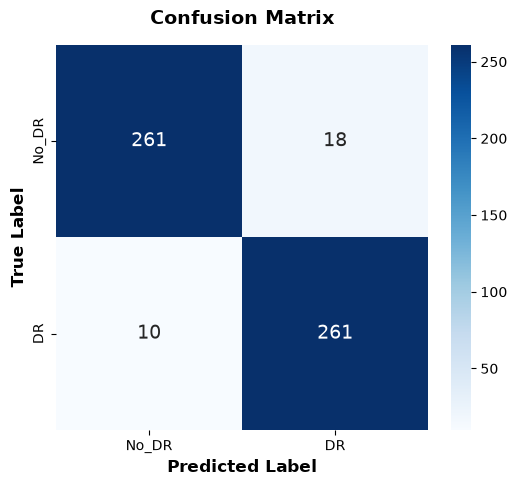


3. LEARNING CURVES (TRAINING VS VALIDATION)


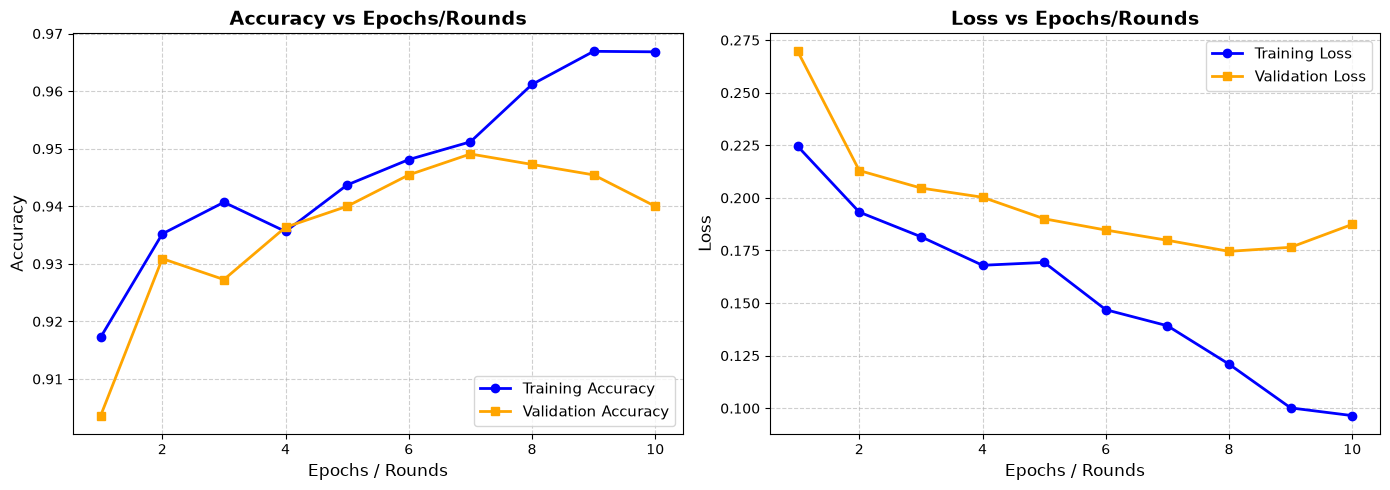


4. ROC AUC CURVE


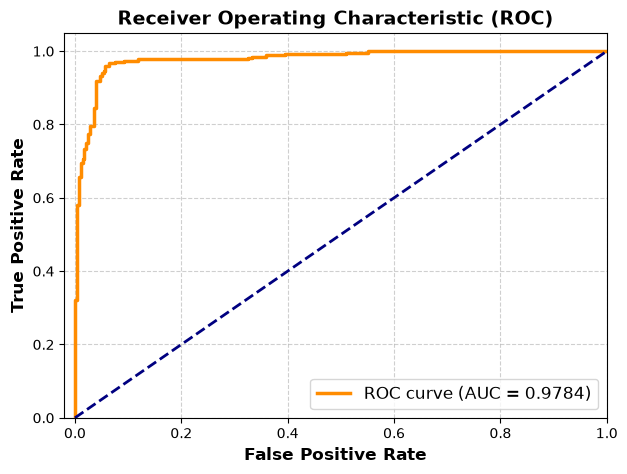


5. PRECISION-RECALL CURVE


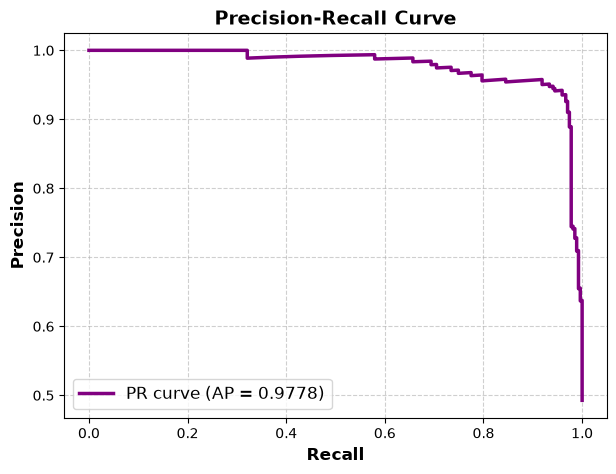

In [10]:
# =========================================================
# 📊 FINAL MODEL EVALUATION & CURVES (RUN IN A NEW CELL)
# =========================================================

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    roc_curve, 
    auc, 
    precision_recall_curve, 
    average_precision_score
)

# ---------------------------------------------------------
# 🛠️ SAFETY CHECK: RE-LOAD DATA IF KERNEL WAS RESTARTED
# ---------------------------------------------------------
if 'val_dataset' not in globals():
    print("⚠️ 'val_dataset' memory mein nahi hai. Dobara load kar rahe hain...")
    try:
        val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
            "val", 
            image_size=(224, 224),
            batch_size=16, 
            label_mode="int"
        ).cache().prefetch(tf.data.AUTOTUNE)
        print("✅ Validation dataset loaded successfully!\n")
    except Exception as e:
        print(f"❌ Error loading data: {e}")
        print("👉 Please make sure folder structure correct hai.")
        raise e
# ---------------------------------------------------------

print("⏳ Loading your FINAL saved model from disk...")
final_model = tf.keras.models.load_model("final_federated_cnn_model.keras")
print("✅ Final Model loaded successfully!")

print("⏳ Generating predictions for all 5 metrics...")

# Get True Labels and Predicted Probabilities
y_true = []
y_prob = []

for images, labels in val_dataset:
    probs = final_model.predict(images, verbose=0)
    y_prob.extend(probs)
    y_true.extend(labels.numpy())

y_true = np.array(y_true)
y_prob = np.array(y_prob)

# Class 1 (DR) ki probability nikalna
y_prob_class1 = y_prob[:, 1]
y_pred = np.argmax(y_prob, axis=1)

print("✅ Predictions completed!\n")


# =========================================================
# 1. CLASSIFICATION REPORT
# =========================================================
print("=" * 60)
print("1. CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=["No_DR", "DR"]))


# =========================================================
# 2. CONFUSION MATRIX
# =========================================================
print("\n" + "=" * 60)
print("2. CONFUSION MATRIX")
print("=" * 60)
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["No_DR", "DR"], 
            yticklabels=["No_DR", "DR"],
            annot_kws={"size": 14})
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix', fontsize=14, fontweight='bold', pad=15)
plt.show()


# =========================================================
# 3. LEARNING CURVES (ACCURACY & LOSS VS EPOCH)
# =========================================================
print("\n" + "=" * 60)
print("3. LEARNING CURVES (TRAINING VS VALIDATION)")
print("=" * 60)

# Check for Federated tracking lists
if 'global_train_acc' in globals() and len(global_train_acc) > 0:
    epochs_range = range(1, len(global_train_acc) + 1)

    plt.figure(figsize=(14, 5))
    
    # Accuracy Curve
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, global_train_acc, label='Training Accuracy', color='blue', lw=2, marker='o')
    plt.plot(epochs_range, global_val_acc, label='Validation Accuracy', color='orange', lw=2, marker='s')
    plt.legend(loc='lower right', fontsize=11)
    plt.title('Accuracy vs Epochs/Rounds', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs / Rounds', fontsize=12)
    plt.ylabel('Accuracy', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)

    # Loss Curve
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, global_train_loss, label='Training Loss', color='blue', lw=2, marker='o')
    plt.plot(epochs_range, global_val_loss, label='Validation Loss', color='orange', lw=2, marker='s')
    plt.legend(loc='upper right', fontsize=11)
    plt.title('Loss vs Epochs/Rounds', fontsize=14, fontweight='bold')
    plt.xlabel('Epochs / Rounds', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

else:
    print("⚠️ Learning curve data memory me nahi hai. Graph plot karne ke liye is cell ko training complete hote hi turant run karein.")


# =========================================================
# 4. ROC AUC CURVE
# =========================================================
print("\n" + "=" * 60)
print("4. ROC AUC CURVE")
print("=" * 60)

fpr, tpr, thresholds = roc_curve(y_true, y_prob_class1)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2.5, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([-0.02, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('Receiver Operating Characteristic (ROC)', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


# =========================================================
# 5. PRECISION-RECALL CURVE
# =========================================================
print("\n" + "=" * 60)
print("5. PRECISION-RECALL CURVE")
print("=" * 60)

precision, recall, _ = precision_recall_curve(y_true, y_prob_class1)
ap_score = average_precision_score(y_true, y_prob_class1)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, color='purple', lw=2.5, label=f'PR curve (AP = {ap_score:.4f})')
plt.xlabel('Recall', fontsize=12, fontweight='bold')
plt.ylabel('Precision', fontsize=12, fontweight='bold')
plt.title('Precision-Recall Curve', fontsize=14, fontweight='bold')
plt.legend(loc="lower left", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

https://chatgpt.com/share/6837f90b-faf8-8013-a0ec-3a2842549225


https://chatgpt.com/share/69a72343-c4f4-8004-aa32-3398b8da4f44

In [11]:
from IPython.display import FileLink
import os

MODEL_PATH = "final_federated_cnn_model.keras"

if os.path.exists(MODEL_PATH):
    print("✅ Model found!")
    print(f"📦 File: {MODEL_PATH}")
    print(f"💾 Size: {os.path.getsize(MODEL_PATH) / (1024**2):.2f} MB")
    display(FileLink(MODEL_PATH))
else:
    print("❌ Model file not found!")
    print(f"Expected file: {MODEL_PATH}")
    print("👉 Pehle merged training cell ko completely finish hone do.")

✅ Model found!
📦 File: final_federated_cnn_model.keras
💾 Size: 3.16 MB


/home/abhiruplinux/retinal files/GRAPH FINAL RETINAL/final_federated_cnn_model.keras